# Pole-pair tradeoff study

How do torque, back-EMF, electrical frequency, core loss, efficiency, and
winding temperature change with pole-pair count?

In the Layer-1 model, torque at fixed air-gap field and electrical loading is
*independent* of pole-pair count (shear stress doesn't depend on `p`) — the
tradeoff lives elsewhere:

- **Low `p`** needs a thick stator yoke: each pole's flux return scales with
  the pole pitch, so a fixed yoke saturates at low pole counts.
- **High `p`** raises electrical frequency linearly — core loss per tesla,
  inverter switching burden, and ripple all grow — while shorter end turns
  reduce copper loss.

In [1]:
from pathlib import Path

from axfluxmdo import AxialFluxMotor, OperatingPoint
from axfluxmdo.sweeps import sweep_pole_pairs

OUTPUT_DIR = Path(__file__).parent / "output" if "__file__" in globals() else Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)
op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)

## Sweep p = 4 … 20

In [3]:
sweep = sweep_pole_pairs(motor, op, pole_pairs=range(4, 21, 2))

data = sweep.to_arrays(
    "torque_nm", "electrical_frequency_hz", "core_loss_w", "efficiency", "winding_temp_c"
)
for p, t, f, pc in zip(
    data["pole_pairs"],
    data["torque_nm"],
    data["electrical_frequency_hz"],
    data["core_loss_w"],
    strict=True,
):
    print(f"p={p:3.0f}  torque={t:6.2f} N·m  f_e={f:6.1f} Hz  core loss={pc:5.2f} W")

p=  4  torque=  8.63 N·m  f_e=  33.3 Hz  core loss= 1.66 W
p=  6  torque=  8.63 N·m  f_e=  50.0 Hz  core loss= 1.35 W
p=  8  torque=  8.63 N·m  f_e=  66.7 Hz  core loss= 1.17 W
p= 10  torque=  8.63 N·m  f_e=  83.3 Hz  core loss= 1.06 W
p= 12  torque=  8.63 N·m  f_e= 100.0 Hz  core loss= 0.98 W
p= 14  torque=  8.63 N·m  f_e= 116.7 Hz  core loss= 0.91 W
p= 16  torque=  8.63 N·m  f_e= 133.3 Hz  core loss= 0.87 W
p= 18  torque=  8.63 N·m  f_e= 150.0 Hz  core loss= 0.83 W
p= 20  torque=  8.63 N·m  f_e= 166.7 Hz  core loss= 0.79 W


## Tradeoff plots

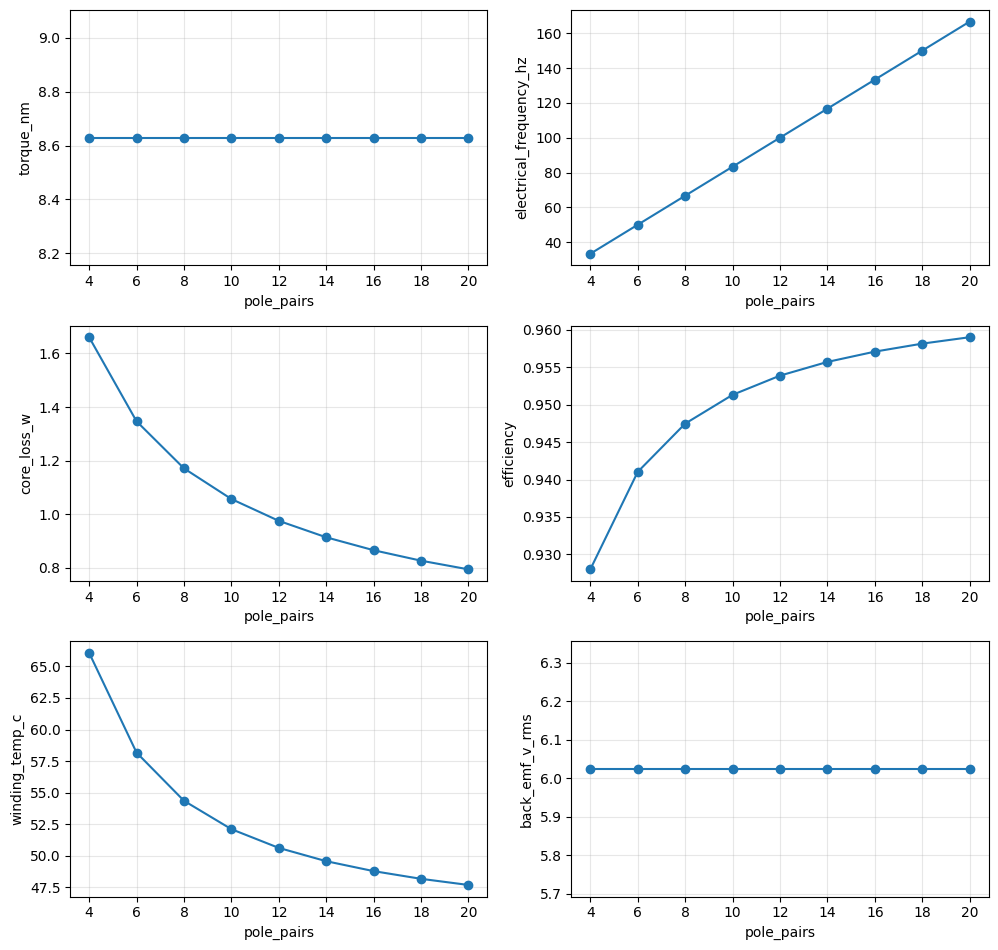

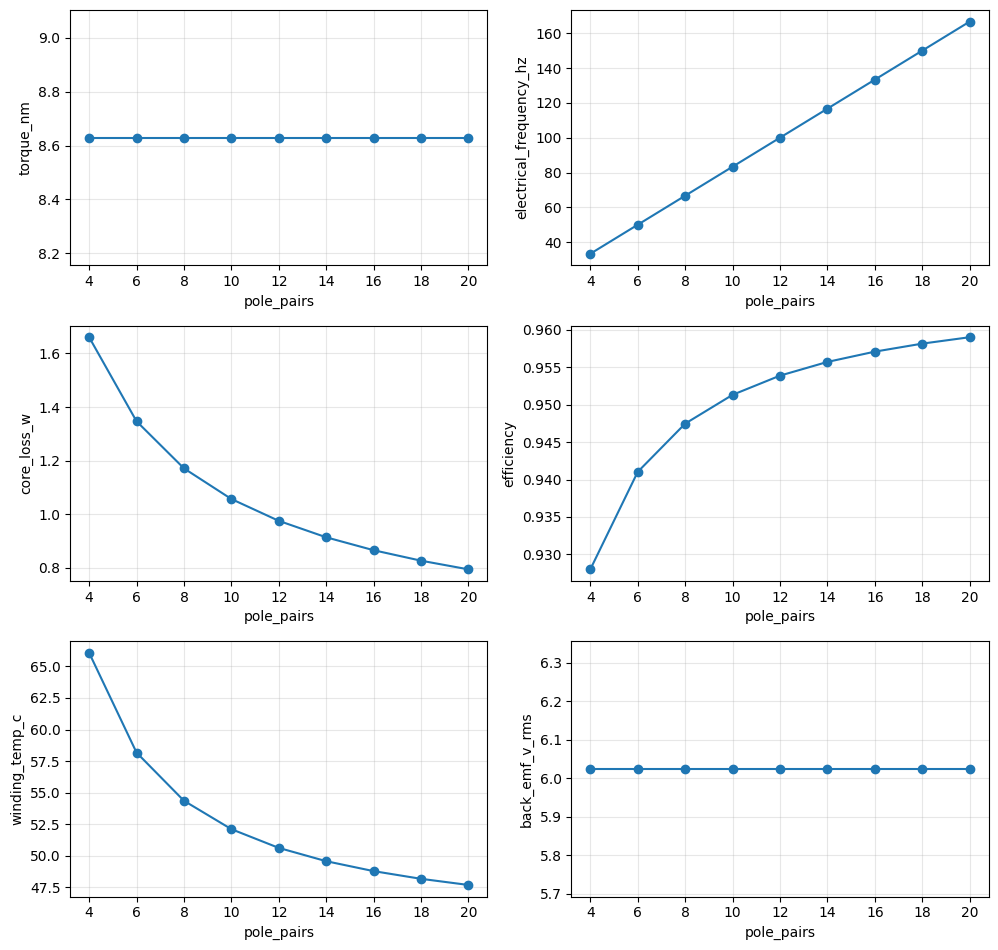

In [4]:
fig = sweep.plot(
    fields=(
        "torque_nm",
        "electrical_frequency_hz",
        "core_loss_w",
        "efficiency",
        "winding_temp_c",
        "back_emf_v_rms",
    )
)
fig.savefig(OUTPUT_DIR / "02_pole_pair_tradeoff.png", dpi=150, bbox_inches="tight")
fig

## Where do constraints bind?

At the low end, p = 4 is infeasible: with the stator core thickness held
fixed, the wide pole pitch pushes the yoke flux density past saturation. At
the high end the electrical-frequency margin shrinks linearly with `p`; at
500 rpm it never binds, but at higher shaft speeds it becomes the limiting
constraint well before thermal limits.

In [5]:
for p, r in zip(sweep.values, sweep.results, strict=True):
    by_name = {c.name: c for c in r.constraints}
    f_margin = by_name["electrical_frequency_hz"].margin
    b_yoke = by_name["core_flux_density_t"].value
    print(f"p={p:3d}  f_e margin {f_margin:+.1%}  B_yoke={b_yoke:.2f} T  feasible={r.feasible}")

p=  4  f_e margin +96.7%  B_yoke=2.34 T  feasible=False
p=  6  f_e margin +95.0%  B_yoke=1.56 T  feasible=True
p=  8  f_e margin +93.3%  B_yoke=1.17 T  feasible=True
p= 10  f_e margin +91.7%  B_yoke=0.94 T  feasible=True
p= 12  f_e margin +90.0%  B_yoke=0.78 T  feasible=True
p= 14  f_e margin +88.3%  B_yoke=0.67 T  feasible=True
p= 16  f_e margin +86.7%  B_yoke=0.59 T  feasible=True
p= 18  f_e margin +85.0%  B_yoke=0.52 T  feasible=True
p= 20  f_e margin +83.3%  B_yoke=0.47 T  feasible=True
